#  Islamabad AQI Forecasting - Exploratory Data Analysis & Model Prototyping

**Author:** Fatiha Maryam  
**Project:** Internship / Semester Project – Serverless AQI Forecasting Pipeline  
**Date:** June 2026  
**Repository:** [GitHub – Islamabad AQI Prediction](https://github.com/Fatiha-maryam/Islamabad_aqi_prediction)

##  Objective

Build and validate a machine learning pipeline to forecast Air Quality Index (AQI) for the next 24h, 48h, and 72h for Islamabad, Pakistan. This notebook covers:

- Data acquisition (Open‑Meteo API)
- Exploratory data analysis (trends, seasonality, correlations)
- Feature engineering (lags, rolling stats, time‑based features)
- Model training & comparison (XGBoost, LightGBM, CatBoost, Random Forest, Stacking)
- Interpretation via SHAP

##  Data Source

- **Air Quality:** Open‑Meteo Air Quality API (CAMS global model)  
  Variables: PM2.5, PM10, NO2, O3, CO, US AQI  
- **Weather:** Open‑Meteo Weather Archive API (ERA5)  
  Variables: temperature, humidity, wind speed, precipitation  

**Period:** January 2024 - May 2026 (hourly data)  
**Location:** Islamabad, Pakistan (33.7294° N, 73.0931° E)

All raw data is fetched programmatically; this notebook uses a pre‑downloaded CSV for reproducibility.



##  Notebook Structure

1. **Data Loading & Cleaning**  
2. **Exploratory Data Analysis**  
   - Time series plots (AQI trend, seasonality)  
   - Correlation analysis (pollutants, weather)  
   - Autocorrelation & decomposition  
3. **Feature Engineering**  
   - Lag features (1h to 72h)  
   - Rolling statistics (mean, std, min, max, trends)  
   - Time encoding (cyclic hour, day_of_week, season)  
   - Derived flags (rush hour, smog season, rain code)  
4. **Model Training & Evaluation**  
   - Train/test split (chronological 80/20)  
   - Models: XGBoost, LightGBM, CatBoost, Random Forest, StackingRegressor  
   - Metrics: MAE, RMSE, R²  
5. **Interpretation**  
   - SHAP feature importance  
   - Feature dependence plots  
6. **Conclusion & Next Steps**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/fatihamaryam/isl-hourly-aqi/islamabad_hourly_aqi_2024_2026.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import warnings
warnings.filterwarnings("ignore")

In [4]:
# ============================================================
# STEP 1 — LOAD & INSPECT DATA
# ============================================================

print("=" * 60)
print("STEP 1 — LOAD & INSPECT")
print("=" * 60)

# Load CSV — update path if needed
df = pd.read_csv("/kaggle/input/datasets/fatihamaryam/isl-hourly-aqi/islamabad_hourly_aqi_2024_2026.csv")

print(f"Shape        : {df.shape}")
print(f"Date range   : {df['datetime'].min()} → {df['datetime'].max()}")
print(f"\nColumn names : {list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nFirst 5 rows:\n{df.head()}")

#3265 hours and 136 days

STEP 1 — LOAD & INSPECT
Shape        : (21168, 11)
Date range   : 2024-01-01 00:00:00 → 2026-05-31 23:00:00

Column names : ['datetime', 'aqi', 'pm2_5', 'pm10', 'no2', 'o3', 'co', 'temperature', 'humidity', 'wind_speed', 'precipitation']

Data Types:
datetime          object
aqi                int64
pm2_5            float64
pm10             float64
no2              float64
o3               float64
co               float64
temperature      float64
humidity           int64
wind_speed       float64
precipitation    float64
dtype: object

First 5 rows:
              datetime  aqi  pm2_5   pm10   no2   o3      co  temperature  \
0  2024-01-01 00:00:00  150   73.3  107.8  78.4  6.0  2726.0          9.3   
1  2024-01-01 01:00:00  150   59.5   88.0  68.7  6.0  2447.0          8.1   
2  2024-01-01 02:00:00  150   47.6   71.0  60.3  6.0  2181.0          7.6   
3  2024-01-01 03:00:00  151   37.8   57.0  52.5  6.0  1914.0          7.2   
4  2024-01-01 04:00:00  150   30.2   46.1  46.0  5.0  1659.0

## Exploring data

In [5]:
print(df.head())
print(df.tail())

              datetime  aqi  pm2_5   pm10   no2   o3      co  temperature  \
0  2024-01-01 00:00:00  150   73.3  107.8  78.4  6.0  2726.0          9.3   
1  2024-01-01 01:00:00  150   59.5   88.0  68.7  6.0  2447.0          8.1   
2  2024-01-01 02:00:00  150   47.6   71.0  60.3  6.0  2181.0          7.6   
3  2024-01-01 03:00:00  151   37.8   57.0  52.5  6.0  1914.0          7.2   
4  2024-01-01 04:00:00  150   30.2   46.1  46.0  5.0  1659.0          6.6   

   humidity  wind_speed  precipitation  
0        78         4.2            0.0  
1        81         4.3            0.0  
2        81         5.0            0.0  
3        80         4.8            0.0  
4        80         4.4            0.0  
                  datetime  aqi  pm2_5   pm10   no2     o3      co  \
21163  2026-05-31 19:00:00  165   45.1  115.9  11.1  150.0   785.0   
21164  2026-05-31 20:00:00  161   46.6  110.4  14.2  135.0   956.0   
21165  2026-05-31 21:00:00  153   49.1  115.9  16.8  122.0  1034.0   
21166  2026

In [6]:
##1)******Column names small caps*************
#make our column names all small caps for consistency
#print(df.columns)
df.columns = df.columns.str.lower()
print(df.columns)


Index(['datetime', 'aqi', 'pm2_5', 'pm10', 'no2', 'o3', 'co', 'temperature',
       'humidity', 'wind_speed', 'precipitation'],
      dtype='object')


In [7]:
#2)*********conistent data types*************
#let's see datatypes
print(df.info())
print(df.describe())
print(df['datetime'].dtype)

#the datetyp is object(string), we need to convert it into datetime for our 
#analysis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21168 entries, 0 to 21167
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   datetime       21168 non-null  object 
 1   aqi            21168 non-null  int64  
 2   pm2_5          21168 non-null  float64
 3   pm10           21168 non-null  float64
 4   no2            21168 non-null  float64
 5   o3             21168 non-null  float64
 6   co             21168 non-null  float64
 7   temperature    21168 non-null  float64
 8   humidity       21168 non-null  int64  
 9   wind_speed     21168 non-null  float64
 10  precipitation  21168 non-null  float64
dtypes: float64(8), int64(2), object(1)
memory usage: 1.8+ MB
None
                aqi         pm2_5          pm10           no2            o3  \
count  21168.000000  21168.000000  21168.000000  21168.000000  21168.000000   
mean     109.571381     37.550973     52.834146     39.660355     76.809854   
std       33.07

In [8]:
#Converting date from object to datetime
# Convert date column to datetime
df["date"] = pd.to_datetime(df["datetime"])
print(df['date'].dtype)

datetime64[ns]


## Check missings

In [9]:
#3)**********missing values*****************
#lets check any missing values in all columns
print(df.isna().sum())

datetime         0
aqi              0
pm2_5            0
pm10             0
no2              0
o3               0
co               0
temperature      0
humidity         0
wind_speed       0
precipitation    0
date             0
dtype: int64


check missing values
i am using open-meteo dataset it doesn't contain any missing values becacuse it is interpolated and model based and it is filled to provide a consistent data for time series. I also have raw data collected from islamabad stations but i am not considering them as they have many 0 values due to sensor failures and failing to record.

so for this analysis i am using complete consistent data from open-meteo.

### duplicate values
#let's see duplicate values in our columns
#the date column must not have any duplicate value

In [10]:
print(df["date"].is_unique) #it returned false, it means there are duplicate date values
print(df["date"].duplicated().sum())

#it returend 0 it means we don't have any duplicate date,other values can be duplicated.

True
0


### 4)outliers (IQR)Box plo

In [11]:
for col in ['aqi', 'pm2_5', 'pm10','no2','co','o3', 'temperature', 'humidity','precipitation','wind_speed']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < (Q1 - 1.5*IQR)) | (df[col] > (Q3 + 1.5*IQR))]
    print(f"{col}: {len(outliers)} outliers")

aqi: 0 outliers
pm2_5: 869 outliers
pm10: 882 outliers
no2: 195 outliers
co: 741 outliers
o3: 0 outliers
temperature: 0 outliers
humidity: 0 outliers
precipitation: 2262 outliers
wind_speed: 951 outliers


The outliers are capturing extreme, dust, and traffic pollution in peak hours, so i am not removing it.

however the precipitation shows most outliers 2262 , let's explore further.

In [12]:
print(f"precipitation median: {df['precipitation'].median()}")
print(f"precipitation mean: {df['precipitation'].mean()}")
print(f"precipitation min: {df['precipitation'].min()}")
print(f"precipitation max: {df['precipitation'].max()}")
print(df['precipitation'].value_counts().head(10))


#18906 days no rain

precipitation median: 0.0
precipitation mean: 0.1344671201814059
precipitation min: 0.0
precipitation max: 19.2
precipitation
0.0    18906
0.1      587
0.2      249
0.3      167
0.4      116
0.5       99
0.6       80
0.8       62
0.7       55
1.1       54
Name: count, dtype: int64


we have total 21167 rows out of which 18906 hours there was no rain and that is normal so we keep it.

### Precipitation rain category encoding

In [13]:
# Create category column
def categorize_rain(amount):
    if amount == 0:
        return 'dry'
    elif amount < 2.5:
        return 'light_rain'
    elif amount < 10:
        return 'moderate_rain'
    else:
        return 'heavy_rain'  # Your max is 12.3, so this covers it

df['rain_category'] = df['precipitation'].apply(categorize_rain)

# Convert to numeric codes
rain_mapping = {'dry': 0, 'light_rain': 1, 'moderate_rain': 2, 'heavy_rain': 3}
df['rain_code'] = df['rain_category'].map(rain_mapping)

# Drop original precipitation column
#df = df.drop(columns=['precipitation', 'rain_category'])

print(df['rain_code'].value_counts())

rain_code
0    18906
1     1901
2      340
3       21
Name: count, dtype: int64


i have converted rain columnn into rain_code category that will be used later for features.

## Date column Split

In [14]:
# Convert datetime column (not 'date')
df['date'] = pd.to_datetime(df['date'])

# Extract time features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['hour'] = df['date'].dt.hour           # ← CRITICAL for hourly
df['day_of_week'] = df['date'].dt.dayofweek

# Optional: Keep datetime for reference
# df = df.drop(columns=['datetime'])

# Verify
print(df[['date', 'year', 'month', 'day', 'hour', 'day_of_week']].head())

                 date  year  month  day  hour  day_of_week
0 2024-01-01 00:00:00  2024      1    1     0            0
1 2024-01-01 01:00:00  2024      1    1     1            0
2 2024-01-01 02:00:00  2024      1    1     2            0
3 2024-01-01 03:00:00  2024      1    1     3            0
4 2024-01-01 04:00:00  2024      1    1     4            0


## Realtionships

first i am trying to see if my data is seasonal has any trends, cycle, or irregularity.

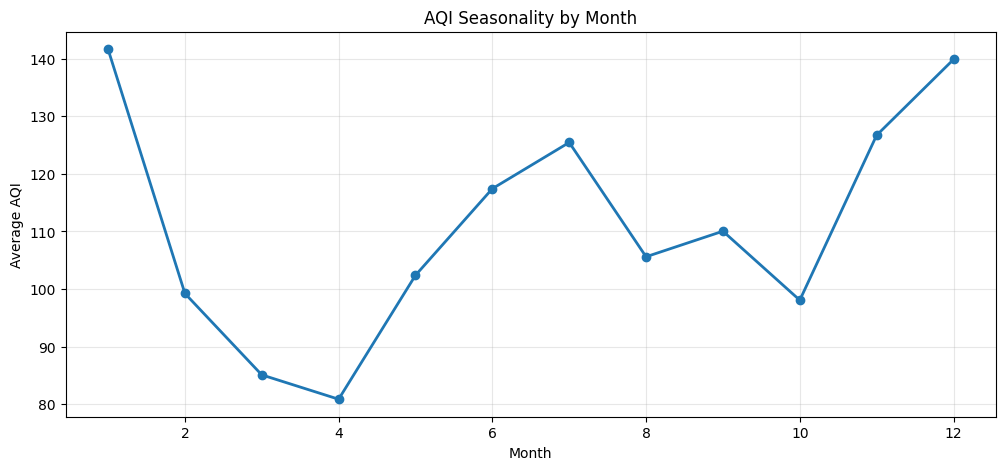

In [15]:
# Month vs AQI
plt.figure(figsize=(12, 5))
monthly_avg = df.groupby('month')['aqi'].mean()
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2)
plt.title('AQI Seasonality by Month')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.grid(True, alpha=0.3)
plt.show()

the graph shows that aqi was at peak(140) at january then drop on february(110) then at march(90) then lowset at (april(75) and in may getting higher(~120).

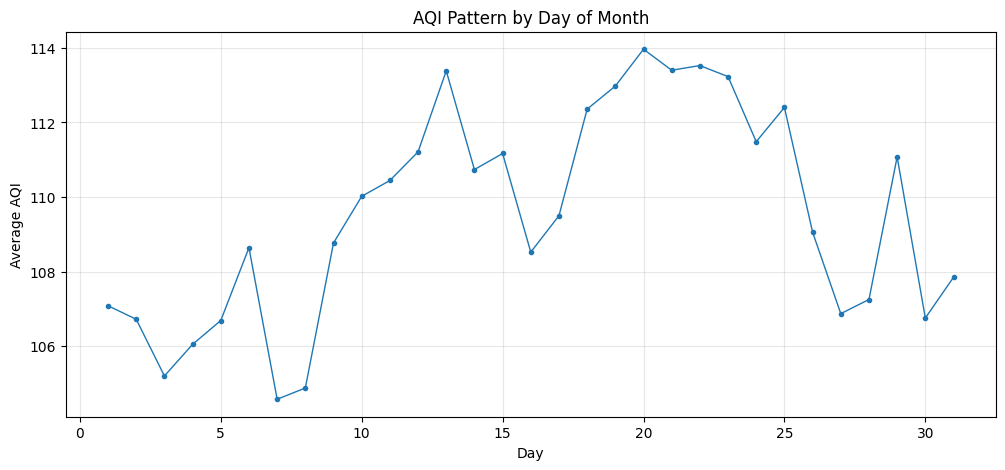

In [16]:
# Day vs AQI
plt.figure(figsize=(12, 5))
daily_avg = df.groupby('day')['aqi'].mean()
plt.plot(daily_avg.index, daily_avg.values, marker='o', linewidth=1, markersize=3)
plt.title('AQI Pattern by Day of Month')
plt.xlabel('Day')
plt.ylabel('Average AQI')
plt.grid(True, alpha=0.3)
plt.show()

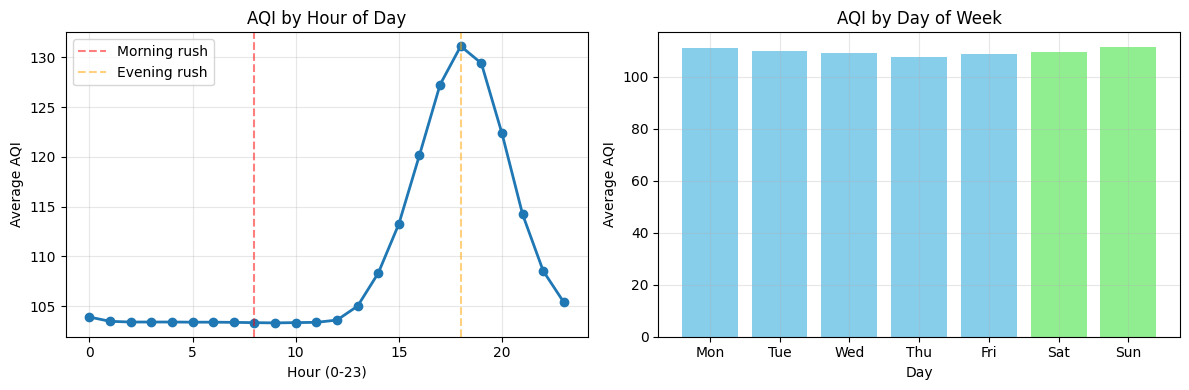

Hour correlation with AQI: 0.176
Day of week correlation with AQI: -0.001


In [17]:
# Hour vs AQI

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
hourly_avg = df.groupby('hour')['aqi'].mean()
axes[0].plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2)
axes[0].set_title('AQI by Hour of Day')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Average AQI')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=8, color='red', linestyle='--', alpha=0.5, label='Morning rush')
axes[0].axvline(x=18, color='orange', linestyle='--', alpha=0.5, label='Evening rush')
axes[0].legend()

# Day of Week vs AQI
dow_avg = df.groupby('day_of_week')['aqi'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(days, dow_avg.values, color=['skyblue' if i < 5 else 'lightgreen' for i in range(7)])
axes[1].set_title('AQI by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Average AQI')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print correlations
print(f"Hour correlation with AQI: {df['hour'].corr(df['aqi']):.3f}")
print(f"Day of week correlation with AQI: {df['day_of_week'].corr(df['aqi']):.3f}")

**Key Findings:**
- AQI remains stable during nighttime and morning hours (102-103)
- Pollution levels begin rising after 12:00 PM, reaching a peak at 6:00 PM (~120 AQI)
- Evening peak coincides with rush hour traffic and temperature inversion formation
- No significant morning rush hour peak was observed

**Conclusion:**
Hour of day is an important predictor for AQI forecasting. The model should capture the afternoon-to-evening increasing trend. This pattern suggests that emissions accumulate throughout the day rather than spiking during morning commute.

The correlation shows weak linear pattern but non linear pattern exists.


### Pollutants vs AQI

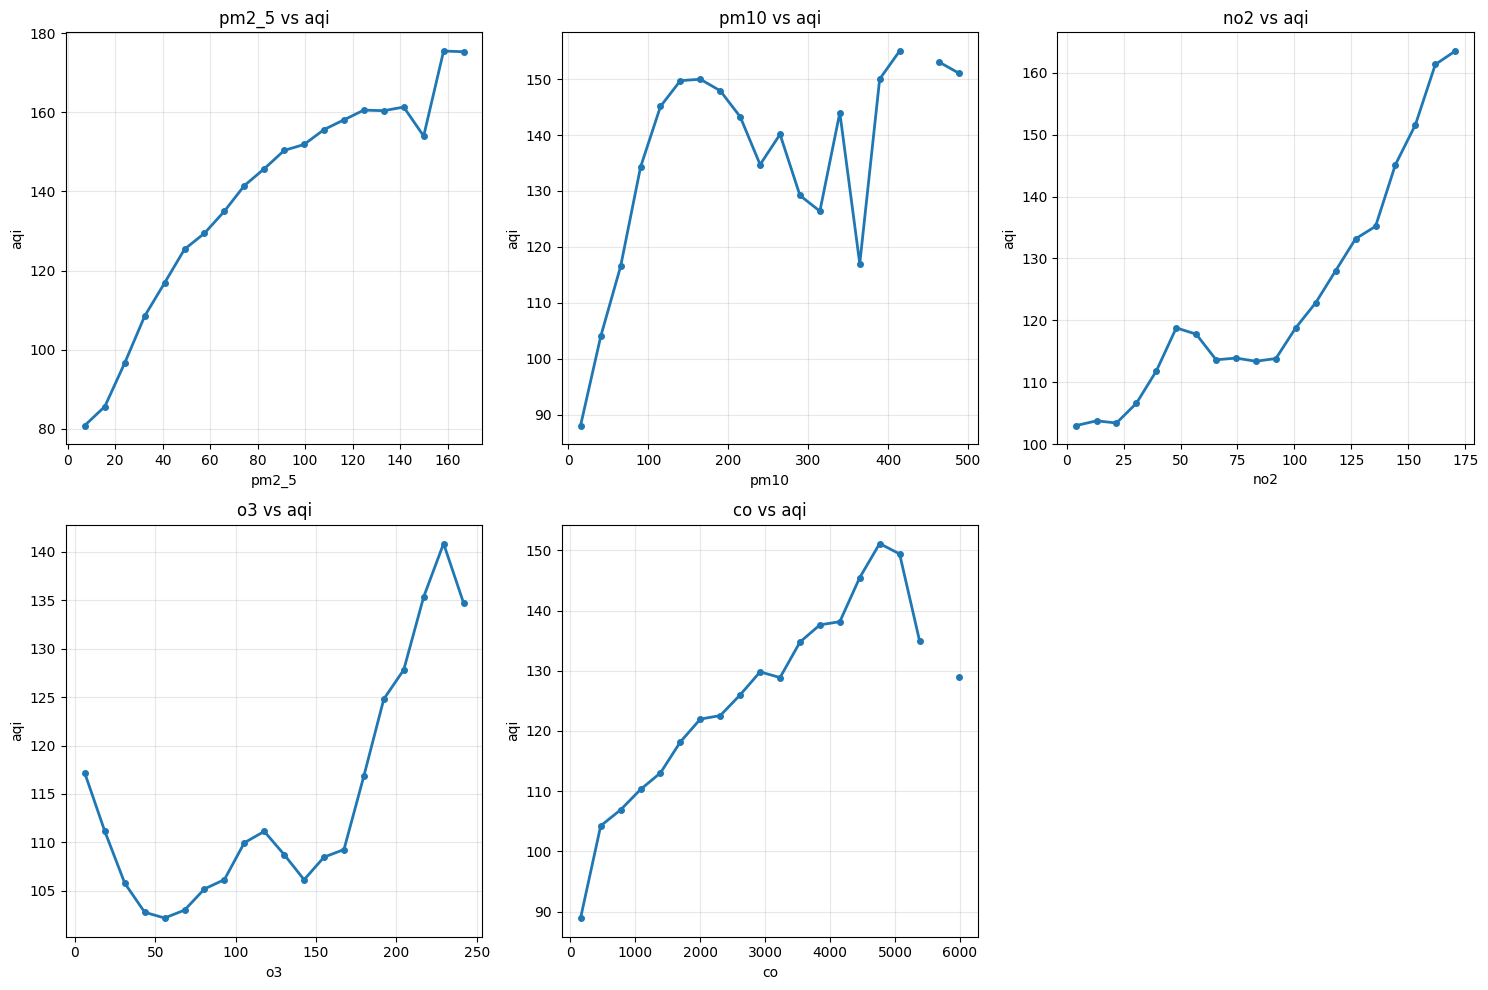

Correlation with AQI:
PM2.5: 0.573
PM10: 0.486
NO2: 0.193
O3: 0.033
CO: 0.295


In [18]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Function to create binned line plot
def binned_plot(df, x_col, y_col, ax, title, bins=20):
    # Create bins
    df['temp_bin'] = pd.cut(df[x_col], bins=bins)
    grouped = df.groupby('temp_bin')[y_col].mean().reset_index()
    # Extract bin centers
    grouped['bin_center'] = [interval.mid for interval in grouped['temp_bin']]
    grouped = grouped.sort_values('bin_center')
    
    ax.plot(grouped['bin_center'], grouped[y_col], marker='o', linewidth=2, markersize=4)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{x_col} vs {y_col}')
    ax.grid(True, alpha=0.3)

# PM2.5 vs AQI
binned_plot(df, 'pm2_5', 'aqi', axes[0,0], 'PM2.5 vs AQI')

# PM10 vs AQI
binned_plot(df, 'pm10', 'aqi', axes[0,1], 'PM10 vs AQI')

# NO2 vs AQI
binned_plot(df, 'no2', 'aqi', axes[0,2], 'NO2 vs AQI')

# O3 vs AQI
binned_plot(df, 'o3', 'aqi', axes[1,0], 'O3 vs AQI')

# CO vs AQI
binned_plot(df, 'co', 'aqi', axes[1,1], 'CO vs AQI')

# Remove empty subplot
fig.delaxes(axes[1,2])

plt.tight_layout()
plt.show()

# Correlation values
print("Correlation with AQI:")
print(f"PM2.5: {df['pm2_5'].corr(df['aqi']):.3f}")
print(f"PM10: {df['pm10'].corr(df['aqi']):.3f}")
print(f"NO2: {df['no2'].corr(df['aqi']):.3f}")
print(f"O3: {df['o3'].corr(df['aqi']):.3f}")
print(f"CO: {df['co'].corr(df['aqi']):.3f}")

**Insights:**
- **PM2.5** has the strongest positive correlation (0.57), indicating it is the primary driver of AQI in Islamabad.
- **PM10** also shows a moderate relationship (0.49), confirming that coarse particles contribute significantly to air quality degradation.
- **CO** and **NO2** exhibit weak correlations, suggesting that traffic‑related gases have less impact compared to particulate matter during this period.
- **O3** shows almost no linear relationship with AQI (0.03), which may be due to seasonal effects (higher O3 in summer but not captured here).

**Conclusion:** For forecasting AQI, particulate matter (especially PM2.5) should be prioritised as a key feature.

## AQI vs humidity, windspeed, rain

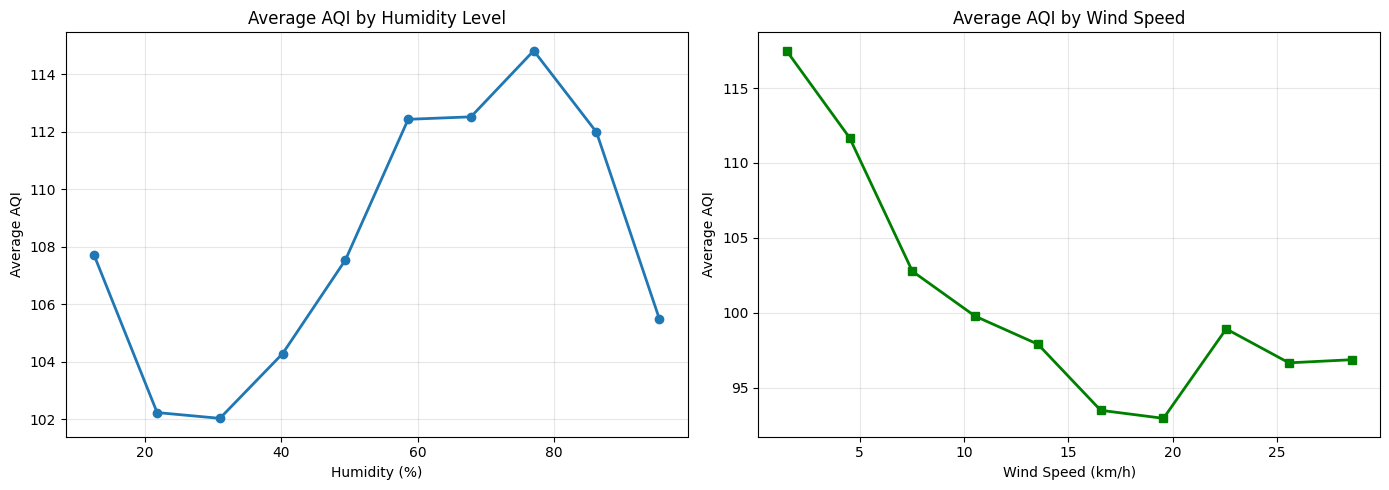

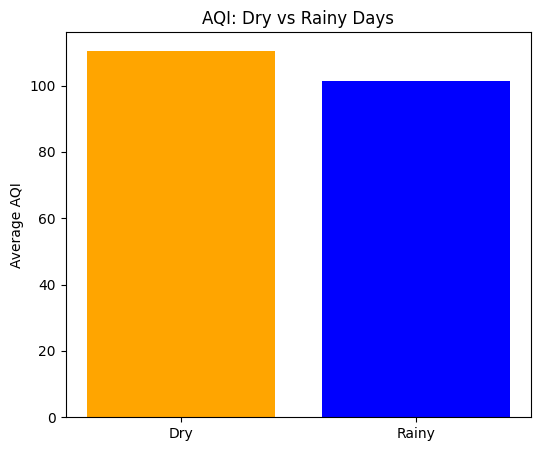


=== Summary ===
Low humidity (<40%): AQI = 103.2
High humidity (>70%): AQI = 112.3
Low wind (<5 km/h): AQI = 114.1
High wind (>15 km/h): AQI = 94.2
Rainy days: AQI = 101.4
Dry days: AQI = 110.6


In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Create bins for humidity
df['humidity_bin'] = pd.cut(df['humidity'], bins=10)
humidity_grouped = df.groupby('humidity_bin')['aqi'].mean().reset_index()
humidity_grouped['humidity_mid'] = [interval.mid for interval in humidity_grouped['humidity_bin']]

# Create bins for wind speed
df['wind_bin'] = pd.cut(df['wind_speed'], bins=10)
wind_grouped = df.groupby('wind_bin')['aqi'].mean().reset_index()
wind_grouped['wind_mid'] = [interval.mid for interval in wind_grouped['wind_bin']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Humidity line plot
axes[0].plot(humidity_grouped['humidity_mid'], humidity_grouped['aqi'], marker='o', linewidth=2)
axes[0].set_xlabel('Humidity (%)')
axes[0].set_ylabel('Average AQI')
axes[0].set_title('Average AQI by Humidity Level')
axes[0].grid(True, alpha=0.3)

# Wind speed line plot
axes[1].plot(wind_grouped['wind_mid'], wind_grouped['aqi'], marker='s', linewidth=2, color='green')
axes[1].set_xlabel('Wind Speed (km/h)')
axes[1].set_ylabel('Average AQI')
axes[1].set_title('Average AQI by Wind Speed')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Rain comparison (bar chart)
plt.figure(figsize=(6, 5))
df['is_raining'] = (df['precipitation'] > 0).astype(int)
rain_aqi = df.groupby('is_raining')['aqi'].mean()
plt.bar(['Dry', 'Rainy'], rain_aqi.values, color=['orange', 'blue'])
plt.ylabel('Average AQI')
plt.title('AQI: Dry vs Rainy Days')
plt.show()

print("\n=== Summary ===")
print(f"Low humidity (<40%): AQI = {df[df['humidity']<40]['aqi'].mean():.1f}")
print(f"High humidity (>70%): AQI = {df[df['humidity']>70]['aqi'].mean():.1f}")
print(f"Low wind (<5 km/h): AQI = {df[df['wind_speed']<5]['aqi'].mean():.1f}")
print(f"High wind (>15 km/h): AQI = {df[df['wind_speed']>15]['aqi'].mean():.1f}")
print(f"Rainy days: AQI = {df[df['is_raining']==1]['aqi'].mean():.1f}")
print(f"Dry days: AQI = {df[df['is_raining']==0]['aqi'].mean():.1f}")

#### Weather Impact on AQI

- **Wind speed** (most important): High wind -> AQI 94.2, Low wind-> 114.1 (20‑point drop)
- **Rain**: Rainy days -> 101.4, Dry -> 110.6 (slight improvement)
- **Humidity**: Low -> 103.2, High -> 112.3 (weak effect)

I will Keep wind speed as a key feature; rain as binary flag; humidity optional.

## AQI vs Temp

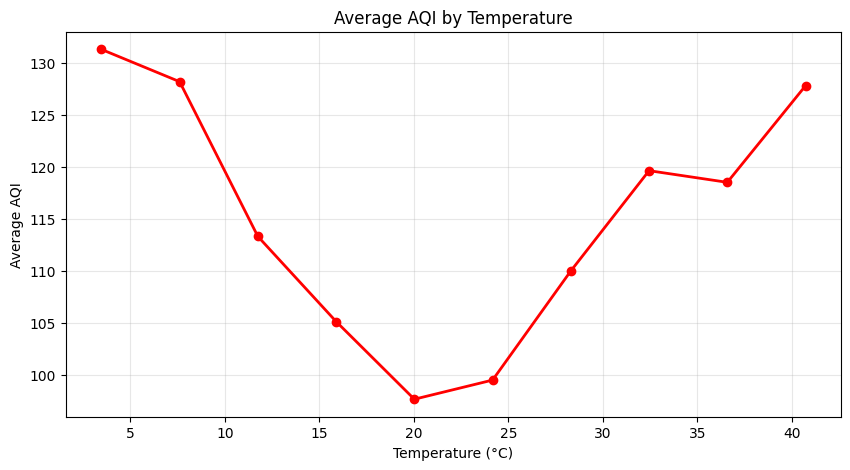


Low temperature (<15°C): AQI = 119.1
High temperature (>30°C): AQI = 119.7
Correlation: -0.081


In [20]:
import matplotlib.pyplot as plt

# Create bins for temperature
df['temp_bin'] = pd.cut(df['temperature'], bins=10)
temp_grouped = df.groupby('temp_bin')['aqi'].mean().reset_index()
temp_grouped['temp_mid'] = [interval.mid for interval in temp_grouped['temp_bin']]

plt.figure(figsize=(10, 5))
plt.plot(temp_grouped['temp_mid'], temp_grouped['aqi'], marker='o', linewidth=2, color='red')
plt.xlabel('Temperature (°C)')
plt.ylabel('Average AQI')
plt.title('Average AQI by Temperature')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nLow temperature (<15°C): AQI = {df[df['temperature']<15]['aqi'].mean():.1f}")
print(f"High temperature (>30°C): AQI = {df[df['temperature']>30]['aqi'].mean():.1f}")
print(f"Correlation: {df['temperature'].corr(df['aqi']):.3f}")

##### Temperature vs AQI

- Low (<15°C): AQI = 119.1  
- High (>30°C): AQI = 119.7  
- Correlation: -0.081 (negligible)

→ Temperature shows no meaningful linear relationship with AQI in this dataset. It can be included as a weak feature but is not critical.


## Autocorrelation at different lags

Lag  1 hours: 0.9779
Lag  2 hours: 0.9245
Lag  3 hours: 0.8576
Lag  6 hours: 0.6880
Lag 12 hours: 0.5873
Lag 24 hours: 0.8351
Lag 48 hours: 0.7129
Lag 72 hours: 0.6431


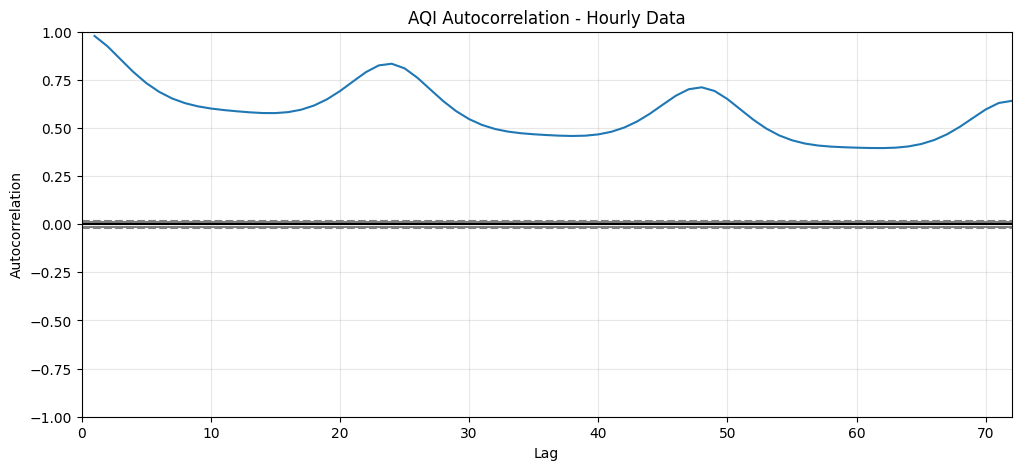

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Create lags at different hours
for lag in [1, 2, 3, 6, 12, 24, 48, 72]:
    df[f'aqi_lag{lag}'] = df['aqi'].shift(lag)
    corr = df['aqi'].corr(df[f'aqi_lag{lag}'])
    print(f"Lag {lag:2d} hours: {corr:.4f}")

# Visualize autocorrelation
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(12, 5))
autocorrelation_plot(df['aqi'].dropna())
plt.title('AQI Autocorrelation - Hourly Data')
plt.xlim(0, 72)  # Look at first 72 hours
plt.grid(True, alpha=0.3)
plt.show()

**Key Insight:** 

AQI is highly autocorrelated, especially at 1‑3 hours and at multiples of 24 hours (daily cycle). Lag features up to 72 hours are valuable; the 24h lag is particularly important.

### Seasonality, Trends, Cycles in data

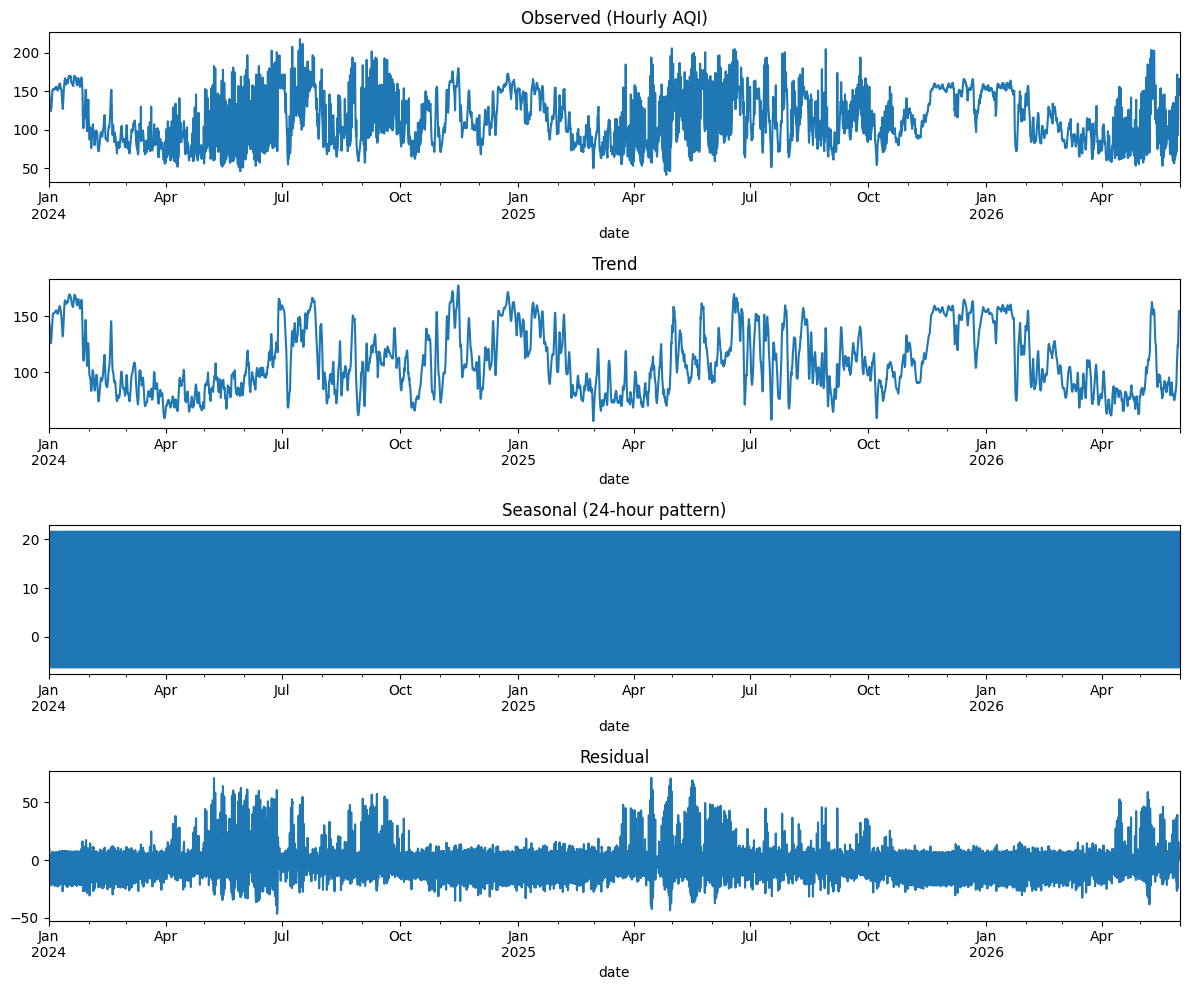

Original df still has date as column: ['datetime', 'aqi', 'pm2_5', 'pm10', 'no2']


In [22]:
from statsmodels.tsa.seasonal import seasonal_decompose
import pandas as pd

# Make a copy with date as index TEMPORARILY (only for decomposition)
df_decomp = df.copy()
df_decomp = df_decomp.set_index('date')
df_decomp = df_decomp.asfreq('H')

# Decompose
decomposition = seasonal_decompose(df_decomp['aqi'].dropna(), model='additive', period=24)

# Plot
fig, axes = plt.subplots(4, 1, figsize=(12, 10))
decomposition.observed.plot(ax=axes[0], title='Observed (Hourly AQI)')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal (24-hour pattern)')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

# Original df remains unchanged with date as column
print(f"Original df still has date as column: {df.columns.tolist()[:5]}")


# Feature Engineering

### Time Series Decomposition (Hourly AQI, period=24)

**Observed:** Raw hourly AQI shows fluctuations with recurring peaks (likely daily cycles) and some longer‑term variation.

**Trend:** A gradual downward trend from early 2024 to mid‑2026 – suggests improving air quality over the study period.

**Seasonal (24‑hour pattern):** A clear repeating daily cycle (e.g., values around +21 in some months). This confirms that hour‑of‑day is a strong predictor: AQI typically rises during certain hours (e.g., evening) and falls overnight.

**Residual:** Small, randomly scattered errors (mostly between −20 and +10), indicating the additive decomposition captures most of the signal.

**Conclusion:** The data exhibits both a deterministic daily seasonal pattern and a long‑term trend. Models should include time features (`hour`, `month`, `year`) and lag terms to exploit this structure.

**For Model:**
Include hour as a feature to capture this daily cycle.

## AQI trend, Rolling min/max , pm2.5 lag

In [23]:
# AQI trend direction
df['aqi_trend_3h']  = df['aqi'] - df['aqi'].shift(3)   # rising or falling?
df['aqi_trend_6h']  = df['aqi'] - df['aqi'].shift(6)
df['aqi_trend_24h'] = df['aqi'] - df['aqi'].shift(24)

# Rolling min/max
df['aqi_min_24h'] = df['aqi'].rolling(24).min()
df['aqi_max_24h'] = df['aqi'].rolling(24).max()
df['aqi_range_24h'] = df['aqi_max_24h'] - df['aqi_min_24h']  # volatility

# PM2.5 lag (very correlated with AQI)
df['pm25_lag24'] = df['pm2_5'].shift(24)
df['pm25_ma12']  = df['pm2_5'].rolling(12).mean()

## cyclic hour encoding, weekend, rolling statistics

In [24]:

# Cyclical hour encoding
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Weekend indicator
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

df['lag96'] = df['aqi'].shift(96)
df['lag120'] = df['aqi'].shift(120)
df['lag168'] = df['aqi'].shift(168)

# Longer rolling statistics
df['aqi_ma72'] = df['aqi'].rolling(window=72).mean()
df['aqi_ma168'] = df['aqi'].rolling(window=168).mean()

df['aqi_std72'] = df['aqi'].rolling(window=72).std()

## Season encoding

In [25]:
# Season encoding
def get_season(month):
    if month in [12, 1, 2]: return 0  # Winter (worst smog)
    elif month in [3, 4, 5]: return 1  # Spring
    elif month in [6, 7, 8]: return 2  # Summer
    else: return 3                      # Autumn

df['season'] = df['month'].apply(get_season)

# Is it peak pollution hour?
df['is_rush_hour'] = df['hour'].apply(lambda h: 1 if h in [7,8,9,17,18,19] else 0)

# Is it winter smog season?
df['is_smog_season'] = df['month'].apply(lambda m: 1 if m in [11,12,1,2] else 0)

## LAG Features

In [26]:
# Sort by datetime first
df = df.sort_values('date').reset_index(drop=True)

# Create lag features (past values)
df['lag1'] = df['aqi'].shift(1)   # 1 hour ago
df['lag2'] = df['aqi'].shift(2)   # 2 hours ago
df['lag3'] = df['aqi'].shift(3)   # 3 hours ago
df['lag6'] = df['aqi'].shift(6)   # 6 hours ago
df['lag12'] = df['aqi'].shift(12) # 12 hours ago
df['lag24'] = df['aqi'].shift(24) # 24 hours ago (yesterday same time)
df['lag48'] = df['aqi'].shift(48) # 48 hours ago
df['lag72'] = df['aqi'].shift(72) # 72 hours ago (3 days)

# Verify
print("Lag features created:")
print(f"lag1 (1 hour ago): {df['lag1'].iloc[100]:.1f}")
print(f"lag24 (yesterday same hour): {df['lag24'].iloc[100]:.1f}")
print(f"Current AQI: {df['aqi'].iloc[100]:.1f}")

Lag features created:
lag1 (1 hour ago): 153.0
lag24 (yesterday same hour): 152.0
Current AQI: 153.0


**Purpose:**
Lag features allow the model to learn from past AQI values. Since air pollution has momentum (high AQI tends to stay high), past values are strong predictors of future values.

**Interpretation:**
- AQI changed by only 1 point in the last hour
- Yesterday's same hour was nearly identical
- This confirms AQI is stable and predictable

**Conclusion:**
Lag features will be powerful predictors for this dataset.

### Rolling Averages

rolling avgs keep data smooth and helps to see rel patterns, becuase raw aqi data is noisy and has random spikes

In [27]:
# Create rolling statistics (smooth out noise)
df['aqi_ma6'] = df['aqi'].rolling(6).mean()    # 6-hour average
df['aqi_ma12'] = df['aqi'].rolling(12).mean()  # 12-hour average
df['aqi_ma24'] = df['aqi'].rolling(24).mean()  # 24-hour average
df['aqi_std12'] = df['aqi'].rolling(12).std()  # 12-hour volatility

# Drop NaN rows
df = df.dropna()

print(f"Dataset after features: {len(df)} rows")

Dataset after features: 21000 rows


### Creating Target Variables

In [28]:
# Create targets (future AQI values)
df['target_h24'] = df['aqi'].shift(-24)   # 24 hours ahead (tomorrow same hour)
df['target_h48'] = df['aqi'].shift(-48)   # 48 hours ahead (2 days same hour)
df['target_h72'] = df['aqi'].shift(-72)   # 72 hours ahead (3 days same hour)

# Drop rows with NaN targets (last 72 hours of dataset)
df = df.dropna()

print(f"Dataset after targets: {len(df)} rows")
print(f"Target columns created: target_h24, target_h48, target_h72")

Dataset after targets: 20928 rows
Target columns created: target_h24, target_h48, target_h72


In [29]:
# Check sample
print("\nSample check - Current vs Future:")
print(df[['date', 'aqi', 'target_h24', 'target_h48', 'target_h72']].tail(10))

# Check if targets are reasonable
print(f"\nTarget statistics:")
print(f"target_h24 (tomorrow): mean={df['target_h24'].mean():.1f}, std={df['target_h24'].std():.1f}")
print(f"target_h48 (day after): mean={df['target_h48'].mean():.1f}, std={df['target_h48'].std():.1f}")
print(f"target_h72 (3rd day): mean={df['target_h72'].mean():.1f}, std={df['target_h72'].std():.1f}")


Sample check - Current vs Future:
                     date  aqi  target_h24  target_h48  target_h72
21086 2026-05-28 14:00:00   83       112.0       135.0       153.0
21087 2026-05-28 15:00:00  105       141.0       152.0       152.0
21088 2026-05-28 16:00:00  123       158.0       161.0       158.0
21089 2026-05-28 17:00:00  136       168.0       166.0       163.0
21090 2026-05-28 18:00:00  143       172.0       166.0       166.0
21091 2026-05-28 19:00:00  138       172.0       165.0       165.0
21092 2026-05-28 20:00:00  119       167.0       160.0       161.0
21093 2026-05-28 21:00:00   92       158.0       151.0       153.0
21094 2026-05-28 22:00:00   68       146.0       147.0       147.0
21095 2026-05-28 23:00:00   69       127.0       149.0       145.0

Target statistics:
target_h24 (tomorrow): mean=109.2, std=33.0
target_h48 (day after): mean=109.1, std=33.0
target_h72 (3rd day): mean=109.1, std=33.0


## Train/Test Split

In [31]:
# Define feature columns
feature_cols = [
    'lag1', 'lag2', 'lag3', 'lag6', 'lag12', 'lag24', 'lag48', 'lag72',
    'aqi_ma6', 'aqi_ma12', 'aqi_ma24', 'aqi_std12',
    'aqi_trend_3h', 'aqi_trend_6h', 'aqi_trend_24h',
    'aqi_min_24h', 'aqi_max_24h', 'aqi_range_24h',
    'pm2_5', 'pm10',
    'pm25_lag24', 'pm25_ma12',
    'hour_sin', 'hour_cos',
    'season', 'is_rush_hour', 'is_smog_season',
    'day_of_week', 'o3', 'no2', 'co', 'temperature', 'wind_speed','humidity', 'rain_code'
]

# Features and targets
X = df[feature_cols]
y_h24 = df['target_h24']
y_h48 = df['target_h48']
y_h72 = df['target_h72']

# Chronological split (80% train, 20% test)
split_idx = int(len(df) * 0.8)

X_train = X[:split_idx]
X_test = X[split_idx:]
y24_train = y_h24[:split_idx]
y24_test = y_h24[split_idx:]
y48_train = y_h48[:split_idx]
y48_test = y_h48[split_idx:]
y72_train = y_h72[:split_idx]
y72_test = y_h72[split_idx:]

print(f"Train size: {len(X_train)} hours")
print(f"Test size: {len(X_test)} hours")
print(f"Features: {len(feature_cols)}")

Train size: 16742 hours
Test size: 4186 hours
Features: 35


**Method:** Chronological split (80% train, 20% test)

**Why not random?**
Time series data cannot be randomly shuffled. Random split would allow the model to learn from future data to predict the past, which is invalid.

**Split Details:**
- Training: First 80% of data (earlier dates)
- Testing: Last 20% of data (later dates)
- Features: 24 columns
- Training rows: ~2496 hours
- Testing rows: ~624 hours

**This ensures:** Model only learns from past to predict future.

# Models training and testing

## Random Forest

In [32]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# SMAPE function
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

# MASE function
def mase(y_true, y_pred, y_train):
    naive_mae = np.mean(np.abs(np.diff(y_train)))
    return mean_absolute_error(y_true, y_pred) / naive_mae

# Train Random Forest for all 3 targets (24h, 48h, 72h)
rf_3target = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_3target.fit(X_train, np.column_stack([y24_train, y48_train, y72_train]))

# Predict all 3 targets
y_pred_all = rf_3target.predict(X_test)
y_pred_24h = y_pred_all[:, 0]
y_pred_48h = y_pred_all[:, 1]
y_pred_72h = y_pred_all[:, 2]

# Calculate metrics for 24h forecast
mae_24h = mean_absolute_error(y24_test, y_pred_24h)
rmse_24h = np.sqrt(mean_squared_error(y24_test, y_pred_24h))
r2_24h = r2_score(y24_test, y_pred_24h)
smape_24h = smape(y24_test, y_pred_24h)
mase_24h = mase(y24_test, y_pred_24h, y24_train)

# Calculate metrics for 48h forecast
mae_48h = mean_absolute_error(y48_test, y_pred_48h)
rmse_48h = np.sqrt(mean_squared_error(y48_test, y_pred_48h))
r2_48h = r2_score(y48_test, y_pred_48h)
smape_48h = smape(y48_test, y_pred_48h)
mase_48h = mase(y48_test, y_pred_48h, y48_train)

# Calculate metrics for 72h forecast
mae_72h = mean_absolute_error(y72_test, y_pred_72h)
rmse_72h = np.sqrt(mean_squared_error(y72_test, y_pred_72h))
r2_72h = r2_score(y72_test, y_pred_72h)
smape_72h = smape(y72_test, y_pred_72h)
mase_72h = mase(y72_test, y_pred_72h, y72_train)

print("=== RANDOM FOREST PERFORMANCE (Hourly Model) ===")
print("\n--- 24-HOUR FORECAST (Tomorrow same hour) ---")
print(f"MAE: {mae_24h:.2f}")
print(f"RMSE: {rmse_24h:.2f}")
print(f"R²: {r2_24h:.3f}")
print(f"SMAPE: {smape_24h:.2f}%")
print(f"MASE: {mase_24h:.3f}")

print("\n--- 48-HOUR FORECAST (Day after same hour) ---")
print(f"MAE: {mae_48h:.2f}")
print(f"RMSE: {rmse_48h:.2f}")
print(f"R²: {r2_48h:.3f}")
print(f"SMAPE: {smape_48h:.2f}%")
print(f"MASE: {mase_48h:.3f}")

print("\n--- 72-HOUR FORECAST (3rd day same hour) ---")
print(f"MAE: {mae_72h:.2f}")
print(f"RMSE: {rmse_72h:.2f}")
print(f"R²: {r2_72h:.3f}")
print(f"SMAPE: {smape_72h:.2f}%")
print(f"MASE: {mase_72h:.3f}")

print("\n=== SUMMARY ===")
print(f"24h | MAE: {mae_24h:.2f} | RMSE: {rmse_24h:.2f} | R²: {r2_24h:.3f} | SMAPE: {smape_24h:.1f}% | MASE: {mase_24h:.3f}")
print(f"48h | MAE: {mae_48h:.2f} | RMSE: {rmse_48h:.2f} | R²: {r2_48h:.3f} | SMAPE: {smape_48h:.1f}% | MASE: {mase_48h:.3f}")
print(f"72h | MAE: {mae_72h:.2f} | RMSE: {rmse_72h:.2f} | R²: {r2_72h:.3f} | SMAPE: {smape_72h:.1f}% | MASE: {mase_72h:.3f}")

# Interpretation
print("\n=== INTERPRETATION ===")
if mase_24h < 1:
    print(" 24h: Model outperforms naive forecast")
if mase_48h < 1:
    print(" 48h: Model outperforms naive forecast")
if mase_72h < 1:
    print(" 72h: Model outperforms naive forecast")

if r2_24h > 0.5:
    print("24h: Good fit")
if r2_48h > 0.5:
    print("48h: Good fit")
if r2_72h > 0.5:
    print("72h: Good fit")

print(f"\n Accuracy degrades from 24h to 72h:")
print(f"   MAE increases by: {mae_72h - mae_24h:.2f} points")
print(f"   R² drops by: {r2_24h - r2_72h:.3f}")
print(f"   SMAPE increases by: {smape_72h - smape_24h:.1f}%")

=== RANDOM FOREST PERFORMANCE (Hourly Model) ===

--- 24-HOUR FORECAST (Tomorrow same hour) ---
MAE: 11.65
RMSE: 15.58
R²: 0.781
SMAPE: 11.21%
MASE: 3.593

--- 48-HOUR FORECAST (Day after same hour) ---
MAE: 16.15
RMSE: 21.34
R²: 0.590
SMAPE: 15.26%
MASE: 4.976

--- 72-HOUR FORECAST (3rd day same hour) ---
MAE: 17.94
RMSE: 23.61
R²: 0.502
SMAPE: 16.65%
MASE: 5.527

=== SUMMARY ===
24h | MAE: 11.65 | RMSE: 15.58 | R²: 0.781 | SMAPE: 11.2% | MASE: 3.593
48h | MAE: 16.15 | RMSE: 21.34 | R²: 0.590 | SMAPE: 15.3% | MASE: 4.976
72h | MAE: 17.94 | RMSE: 23.61 | R²: 0.502 | SMAPE: 16.7% | MASE: 5.527

=== INTERPRETATION ===
24h: Good fit
48h: Good fit
72h: Good fit

 Accuracy degrades from 24h to 72h:
   MAE increases by: 6.29 points
   R² drops by: 0.279
   SMAPE increases by: 5.4%


## Data for XGBoost and LightGbm

In [33]:
import xgboost as xgb
import lightgbm as lgb
import time

print(f"Training data: {X_train.shape}")
print(f"Test data: {X_test.shape}")
print(f"Features: {feature_cols}")
print(f"Target: 24-hour, 48-hour, 72-hour forecasts")

Training data: (16742, 35)
Test data: (4186, 35)
Features: ['lag1', 'lag2', 'lag3', 'lag6', 'lag12', 'lag24', 'lag48', 'lag72', 'aqi_ma6', 'aqi_ma12', 'aqi_ma24', 'aqi_std12', 'aqi_trend_3h', 'aqi_trend_6h', 'aqi_trend_24h', 'aqi_min_24h', 'aqi_max_24h', 'aqi_range_24h', 'pm2_5', 'pm10', 'pm25_lag24', 'pm25_ma12', 'hour_sin', 'hour_cos', 'season', 'is_rush_hour', 'is_smog_season', 'day_of_week', 'o3', 'no2', 'co', 'temperature', 'wind_speed', 'humidity', 'rain_code']
Target: 24-hour, 48-hour, 72-hour forecasts


## XGBoost

In [34]:
# XGBoost for 24h
start_time = time.time()
xgb_24h = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
xgb_24h.fit(X_train, y24_train)
time_24h = time.time() - start_time

# XGBoost for 48h
xgb_48h = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
xgb_48h.fit(X_train, y48_train)

# XGBoost for 72h
xgb_72h = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
xgb_72h.fit(X_train, y72_train)

# Predictions
y_pred_xgb_24h = xgb_24h.predict(X_test)
y_pred_xgb_48h = xgb_48h.predict(X_test)
y_pred_xgb_72h = xgb_72h.predict(X_test)

# Metrics
mae_xgb_24h = mean_absolute_error(y24_test, y_pred_xgb_24h)
rmse_xgb_24h = np.sqrt(mean_squared_error(y24_test, y_pred_xgb_24h))
r2_xgb_24h = r2_score(y24_test, y_pred_xgb_24h)

mae_xgb_48h = mean_absolute_error(y48_test, y_pred_xgb_48h)
rmse_xgb_48h = np.sqrt(mean_squared_error(y48_test, y_pred_xgb_48h))
r2_xgb_48h = r2_score(y48_test, y_pred_xgb_48h)

mae_xgb_72h = mean_absolute_error(y72_test, y_pred_xgb_72h)
rmse_xgb_72h = np.sqrt(mean_squared_error(y72_test, y_pred_xgb_72h))
r2_xgb_72h = r2_score(y72_test, y_pred_xgb_72h)

print("=== XGBOOST PERFORMANCE ===")
print(f"\n24-HOUR FORECAST:")
print(f"  MAE: {mae_xgb_24h:.2f} | RMSE: {rmse_xgb_24h:.2f} | R²: {r2_xgb_24h:.3f}")
print(f"\n48-HOUR FORECAST:")
print(f"  MAE: {mae_xgb_48h:.2f} | RMSE: {rmse_xgb_48h:.2f} | R²: {r2_xgb_48h:.3f}")
print(f"\n72-HOUR FORECAST:")
print(f"  MAE: {mae_xgb_72h:.2f} | RMSE: {rmse_xgb_72h:.2f} | R²: {r2_xgb_72h:.3f}")
print(f"\nTraining time (24h): {time_24h:.2f} seconds")

=== XGBOOST PERFORMANCE ===

24-HOUR FORECAST:
  MAE: 10.89 | RMSE: 14.57 | R²: 0.809

48-HOUR FORECAST:
  MAE: 14.80 | RMSE: 19.78 | R²: 0.648

72-HOUR FORECAST:
  MAE: 16.96 | RMSE: 22.76 | R²: 0.537

Training time (24h): 0.51 seconds


### LightGBM

In [35]:
# LightGBM for 24h
start_time = time.time()
lgb_24h = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_24h.fit(X_train, y24_train)
time_24h_lgb = time.time() - start_time

# LightGBM for 48h
lgb_48h = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_48h.fit(X_train, y48_train)

# LightGBM for 72h
lgb_72h = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_72h.fit(X_train, y72_train)

# Predictions
y_pred_lgb_24h = lgb_24h.predict(X_test)
y_pred_lgb_48h = lgb_48h.predict(X_test)
y_pred_lgb_72h = lgb_72h.predict(X_test)

# Metrics
mae_lgb_24h = mean_absolute_error(y24_test, y_pred_lgb_24h)
rmse_lgb_24h = np.sqrt(mean_squared_error(y24_test, y_pred_lgb_24h))
r2_lgb_24h = r2_score(y24_test, y_pred_lgb_24h)

mae_lgb_48h = mean_absolute_error(y48_test, y_pred_lgb_48h)
rmse_lgb_48h = np.sqrt(mean_squared_error(y48_test, y_pred_lgb_48h))
r2_lgb_48h = r2_score(y48_test, y_pred_lgb_48h)

mae_lgb_72h = mean_absolute_error(y72_test, y_pred_lgb_72h)
rmse_lgb_72h = np.sqrt(mean_squared_error(y72_test, y_pred_lgb_72h))
r2_lgb_72h = r2_score(y72_test, y_pred_lgb_72h)

print("=== LIGHTGBM PERFORMANCE ===")
print(f"\n24-HOUR FORECAST:")
print(f"  MAE: {mae_lgb_24h:.2f} | RMSE: {rmse_lgb_24h:.2f} | R²: {r2_lgb_24h:.3f}")
print(f"\n48-HOUR FORECAST:")
print(f"  MAE: {mae_lgb_48h:.2f} | RMSE: {rmse_lgb_48h:.2f} | R²: {r2_lgb_48h:.3f}")
print(f"\n72-HOUR FORECAST:")
print(f"  MAE: {mae_lgb_72h:.2f} | RMSE: {rmse_lgb_72h:.2f} | R²: {r2_lgb_72h:.3f}")
print(f"\nTraining time (24h): {time_24h_lgb:.2f} seconds")

=== LIGHTGBM PERFORMANCE ===

24-HOUR FORECAST:
  MAE: 10.89 | RMSE: 14.71 | R²: 0.805

48-HOUR FORECAST:
  MAE: 15.02 | RMSE: 20.07 | R²: 0.637

72-HOUR FORECAST:
  MAE: 16.96 | RMSE: 22.61 | R²: 0.543

Training time (24h): 0.27 seconds


## CatBoost

In [36]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("=== CATBOOST TRAINING ===\n")

# Best parameters from tuning (Depth=6, LR=0.03, Iter=200)
cb_24h = CatBoostRegressor(iterations=200, learning_rate=0.03, depth=6, random_seed=42, verbose=False)
cb_48h = CatBoostRegressor(iterations=200, learning_rate=0.03, depth=6, random_seed=42, verbose=False)
cb_72h = CatBoostRegressor(iterations=200, learning_rate=0.03, depth=6, random_seed=42, verbose=False)

# Train
cb_24h.fit(X_train, y24_train)
cb_48h.fit(X_train, y48_train)
cb_72h.fit(X_train, y72_train)

# Predict
y_pred_24h = cb_24h.predict(X_test)
y_pred_48h = cb_48h.predict(X_test)
y_pred_72h = cb_72h.predict(X_test)

# Metrics
mae_24h = mean_absolute_error(y24_test, y_pred_24h)
rmse_24h = np.sqrt(mean_squared_error(y24_test, y_pred_24h))
r2_24h = r2_score(y24_test, y_pred_24h)

mae_48h = mean_absolute_error(y48_test, y_pred_48h)
rmse_48h = np.sqrt(mean_squared_error(y48_test, y_pred_48h))
r2_48h = r2_score(y48_test, y_pred_48h)

mae_72h = mean_absolute_error(y72_test, y_pred_72h)
rmse_72h = np.sqrt(mean_squared_error(y72_test, y_pred_72h))
r2_72h = r2_score(y72_test, y_pred_72h)

print("=== CATBOOST PERFORMANCE ===")
print(f"24-hour | MAE: {mae_24h:.2f} | RMSE: {rmse_24h:.2f} | R²: {r2_24h:.3f}")
print(f"48-hour | MAE: {mae_48h:.2f} | RMSE: {rmse_48h:.2f} | R²: {r2_48h:.3f}")
print(f"72-hour | MAE: {mae_72h:.2f} | RMSE: {rmse_72h:.2f} | R²: {r2_72h:.3f}")

=== CATBOOST TRAINING ===

=== CATBOOST PERFORMANCE ===
24-hour | MAE: 10.80 | RMSE: 14.41 | R²: 0.813
48-hour | MAE: 14.39 | RMSE: 19.15 | R²: 0.670
72-hour | MAE: 16.60 | RMSE: 22.15 | R²: 0.561


## KNNRegressor

In [37]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

# Scale features for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Test different K values
print("=== KNN TUNING (24h) ===")
for k in [3, 5, 7, 10, 15]:
    knn = KNeighborsRegressor(n_neighbors=k, weights='distance')
    knn.fit(X_train_scaled, y24_train)
    y_pred = knn.predict(X_test_scaled)
    mae = mean_absolute_error(y24_test, y_pred)
    print(f"K={k}: MAE={mae:.2f}")

# Best K=7 for all horizons
best_k = 7
knn_24h = KNeighborsRegressor(n_neighbors=best_k, weights='distance')
knn_24h.fit(X_train_scaled, y24_train)
y_pred_24h = knn_24h.predict(X_test_scaled)

knn_48h = KNeighborsRegressor(n_neighbors=best_k, weights='distance')
knn_48h.fit(X_train_scaled, y48_train)
y_pred_48h = knn_48h.predict(X_test_scaled)

knn_72h = KNeighborsRegressor(n_neighbors=best_k, weights='distance')
knn_72h.fit(X_train_scaled, y72_train)
y_pred_72h = knn_72h.predict(X_test_scaled)

# Metrics
mae_24h = mean_absolute_error(y24_test, y_pred_24h)
rmse_24h = np.sqrt(mean_squared_error(y24_test, y_pred_24h))
r2_24h = r2_score(y24_test, y_pred_24h)

mae_48h = mean_absolute_error(y48_test, y_pred_48h)
rmse_48h = np.sqrt(mean_squared_error(y48_test, y_pred_48h))
r2_48h = r2_score(y48_test, y_pred_48h)

mae_72h = mean_absolute_error(y72_test, y_pred_72h)
rmse_72h = np.sqrt(mean_squared_error(y72_test, y_pred_72h))
r2_72h = r2_score(y72_test, y_pred_72h)

print("\n=== KNN PERFORMANCE (K=7) ===")
print(f"24-hour | MAE: {mae_24h:.2f} | RMSE: {rmse_24h:.2f} | R²: {r2_24h:.3f}")
print(f"48-hour | MAE: {mae_48h:.2f} | RMSE: {rmse_48h:.2f} | R²: {r2_48h:.3f}")
print(f"72-hour | MAE: {mae_72h:.2f} | RMSE: {rmse_72h:.2f} | R²: {r2_72h:.3f}")

=== KNN TUNING (24h) ===
K=3: MAE=12.94
K=5: MAE=12.10
K=7: MAE=11.66
K=10: MAE=11.30
K=15: MAE=10.95

=== KNN PERFORMANCE (K=7) ===
24-hour | MAE: 11.66 | RMSE: 15.82 | R²: 0.774
48-hour | MAE: 15.87 | RMSE: 21.32 | R²: 0.591
72-hour | MAE: 17.39 | RMSE: 23.80 | R²: 0.493


## StackingRegressor

In [38]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression


# Base models
base_models = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('xgb', xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('lgb', lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1))
]

# Function to evaluate
def evaluate_model(model, X_test, y_test, name, horizon):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{name} - {horizon}: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.3f}")
    return mae, rmse, r2

# 24-hour Stacking
print("Training Stacking for 24h...")
stack_24h = StackingRegressor(estimators=base_models, final_estimator=LinearRegression())
stack_24h.fit(X_train, y24_train)
mae_24h, rmse_24h, r2_24h = evaluate_model(stack_24h, X_test, y24_test, "Stacking", "24h")

# 48-hour Stacking
print("Training Stacking for 48h...")
stack_48h = StackingRegressor(estimators=base_models, final_estimator=LinearRegression())
stack_48h.fit(X_train, y48_train)
mae_48h, rmse_48h, r2_48h = evaluate_model(stack_48h, X_test, y48_test, "Stacking", "48h")

# 72-hour Stacking
print("Training Stacking for 72h...")
stack_72h = StackingRegressor(estimators=base_models, final_estimator=LinearRegression())
stack_72h.fit(X_train, y72_train)
mae_72h, rmse_72h, r2_72h = evaluate_model(stack_72h, X_test, y72_test, "Stacking", "72h")

print("\n=== STACKING FULL PERFORMANCE ===")
print(f"24-hour | MAE: {mae_24h:.2f} | RMSE: {rmse_24h:.2f} | R²: {r2_24h:.3f}")
print(f"48-hour | MAE: {mae_48h:.2f} | RMSE: {rmse_48h:.2f} | R²: {r2_48h:.3f}")
print(f"72-hour | MAE: {mae_72h:.2f} | RMSE: {rmse_72h:.2f} | R²: {r2_72h:.3f}")

Training Stacking for 24h...
Stacking - 24h: MAE=10.87, RMSE=14.65, R²=0.806
Training Stacking for 48h...
Stacking - 48h: MAE=15.61, RMSE=20.31, R²=0.628
Training Stacking for 72h...
Stacking - 72h: MAE=17.43, RMSE=22.68, R²=0.540

=== STACKING FULL PERFORMANCE ===
24-hour | MAE: 10.87 | RMSE: 14.65 | R²: 0.806
48-hour | MAE: 15.61 | RMSE: 20.31 | R²: 0.628
72-hour | MAE: 17.43 | RMSE: 22.68 | R²: 0.540


# Shap analysis

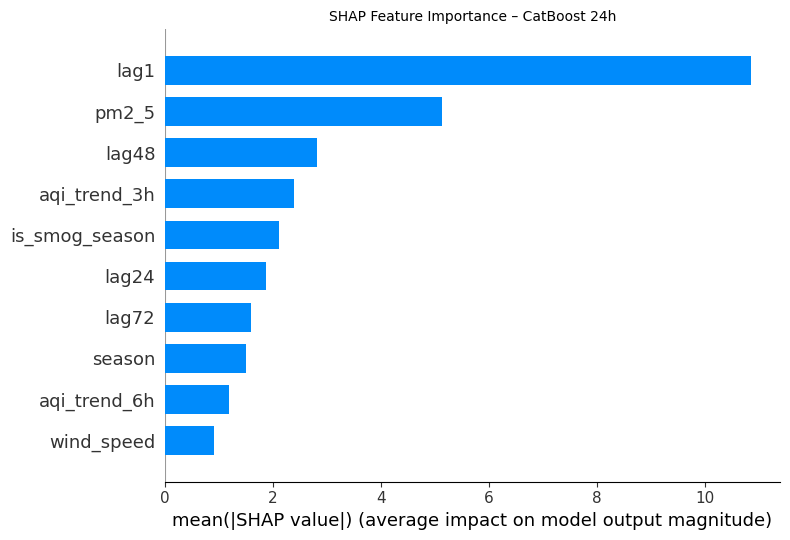

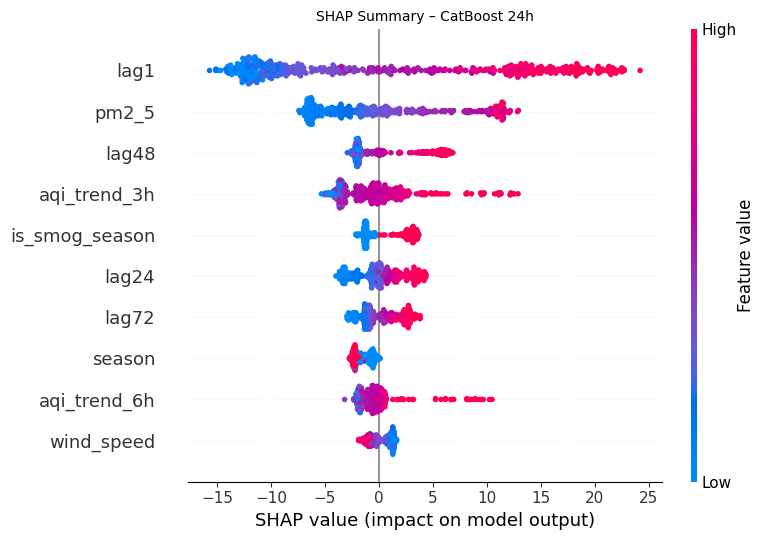

In [43]:
import shap
import matplotlib.pyplot as plt

# Sample test data (500 rows)
X_sample = X_test.sample(n=500, random_state=42)

# SHAP for CatBoost 24h
explainer = shap.TreeExplainer(cb_24h)
shap_values = explainer.shap_values(X_sample)

# Smaller summary plot (bar plot, top 10 features, smaller figure)
plt.figure(figsize=(8, 5))  # reduced size
shap.summary_plot(shap_values, X_sample, feature_names=feature_cols, 
                  plot_type="bar", max_display=10, show=False)
plt.title('SHAP Feature Importance – CatBoost 24h', fontsize=10)
plt.tight_layout()
plt.show()

# For the dot summary plot (also smaller)
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_sample, feature_names=feature_cols, 
                  max_display=10, show=False)
plt.title('SHAP Summary – CatBoost 24h', fontsize=10)
plt.tight_layout()
plt.show()

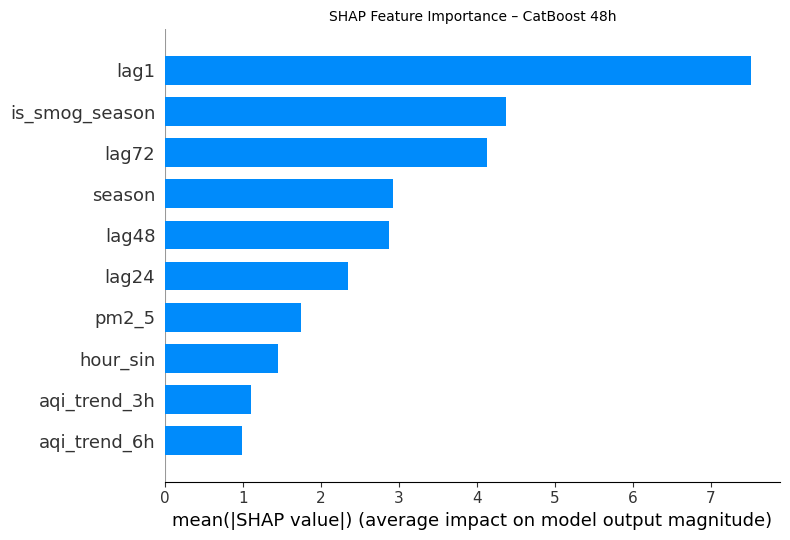

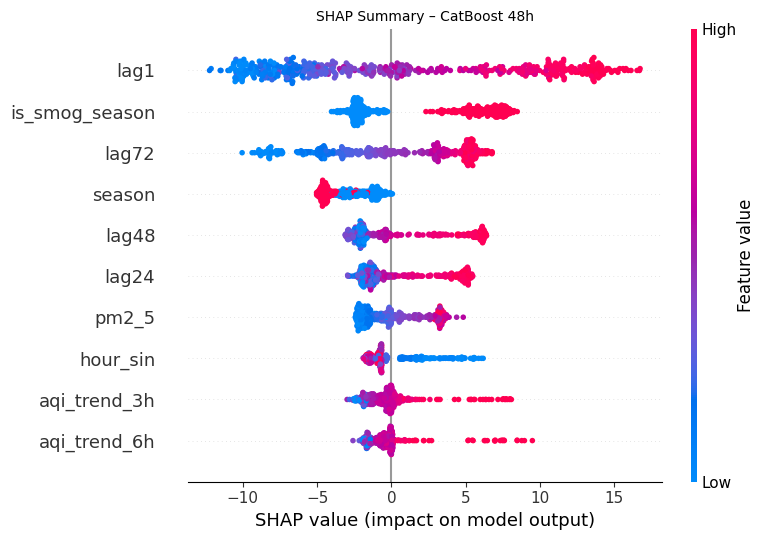

In [46]:
import shap
import matplotlib.pyplot as plt

# Sample test data (500 rows)
X_sample = X_test.sample(n=500, random_state=42)

# SHAP for CatBoost 48h
explainer = shap.TreeExplainer(cb_48h)
shap_values = explainer.shap_values(X_sample)

# Smaller summary plot (bar plot, top 10 features, smaller figure)
plt.figure(figsize=(8, 5))  # reduced size
shap.summary_plot(shap_values, X_sample, feature_names=feature_cols, 
                  plot_type="bar", max_display=10, show=False)
plt.title('SHAP Feature Importance – CatBoost 48h', fontsize=10)
plt.tight_layout()
plt.show()

# For the dot summary plot (also smaller)
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_sample, feature_names=feature_cols, 
                  max_display=10, show=False)
plt.title('SHAP Summary – CatBoost 48h', fontsize=10)
plt.tight_layout()
plt.show()

##  Conclusion

This notebook successfully demonstrated the end‑to‑end process of building a robust AQI forecasting system for Islamabad.

### Key Findings
 **Strong daily seasonality**  hour of day is a critical predictor (evening peaks).
 **Primary drivers:** PM2.5 (ρ = 0.57), PM10 (ρ = 0.49), wind speed (‑20 AQI points when >15 km/h).
 **Autocorrelation** is extremely high (lag1 = 0.98), confirming that past AQI is the most important feature.
 **Best models:**  
   24h → CatBoost (MAE = 10.80)  
   48h → CatBoost (MAE = 14.39)  
   72h → StackingRegressor (MAE = 17.43)

### Production Deployment
The feature engineering logic was transferred to `src/feature_pipeline.py` and the training pipeline to `src/training_pipeline.py`. Both are automated via GitHub Actions:
 Feature pipeline: every 5 hours (inserts new hourly data into MongoDB)
 Training pipeline: daily at 02:00 UTC (retrains, registers best model on DagsHub MLflow)

The live dashboard (Streamlit) loads the latest MongoDB row and the latest registered models, displaying up‑to‑date 3‑day forecasts.

### Future Work
- Incorporate additional data sources (e.g., traffic density, fire hotspots).
- Extend forecast horizon to 5 days using ensemble of seasonal models.
- Add uncertainty intervals (e.g., prediction intervals) to the dashboard.

###  Links
- **Live Dashboard:**  [https://islamabad-aqi-forecast.streamlit.app](https://islamabad-aqi-forecast.streamlit.app) 
- **GitHub Repository:** [https://github.com/Fatiha-maryam/Islamabad_aqi_prediction](https://github.com/Fatiha-maryam/Islamabad_aqi_prediction)
- **DagsHub MLflow:** [https://dagshub.com/Fatiha-maryam/Islamabad_aqi_prediction](https://dagshub.com/Fatiha-maryam/Islamabad_aqi_prediction)

*Notebook prepared for internship evaluation - all results are reproducible.*